# 02 — Análise exploratória

**Projeto Integrador IV · Univesp** — Análise de dados públicos da COVID-19

Atende à atividade da Quinzena 3 *"Realizar análise exploratória inicial das variáveis"*
(10/09 – 17/09) e alimenta *"Identificar variáveis relevantes"* (14/09 – 20/09).

Seis perguntas, nesta ordem:

1. Como foi a evolução de casos e óbitos no Brasil, e quais foram as ondas?
2. Quais UFs tiveram maior incidência e maior mortalidade por 100 mil habitantes?
3. A letalidade aparente mudou ao longo do tempo?
4. A distribuição da incidência entre os municípios é homogênea?
5. Municípios de portes diferentes tiveram curvas de formatos diferentes?
6. Existe padrão semanal na notificação?

> Requisito: `01_ingestao_qualidade.ipynb` executado. Dele vêm duas decisões que valem aqui —
> o nível estadual é o único completo até o fim da série, e a análise municipal é recortada
> em **16/09/2021**.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

from pi4 import CAMINHOS, carregar_municipios, carregar_ufs

CAMINHOS.figuras.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": .25,
    "axes.spines.top": False, "axes.spines.right": False, "figure.autolayout": True,
})

AZUL, VERMELHO, CINZA = "#35608f", "#c25a3a", "#6c665c"
CORTE_MUNICIPAL = pd.Timestamp("2021-09-16")   # ver notebook 01, seção 7
FONTE = "Fonte: Brasil.IO — caso_full"

# y desce quando o eixo x tem rótulo, para o crédito não encavalar
def creditar(ax, y=-.16):
    ax.text(.99, y, FONTE, transform=ax.transAxes, ha="right", fontsize=7, color=CINZA)

def salvar(fig, nome):
    fig.savefig(CAMINHOS.figuras / f"{nome}.png", bbox_inches="tight")
    return CAMINHOS.figuras / f"{nome}.png"

ufs = carregar_ufs(["date", "state", "new_confirmed", "new_deaths",
                    "estimated_population", "last_available_confirmed",
                    "last_available_deaths"])
f"{len(ufs):,} linhas estaduais".replace(",", ".")

'20.119 linhas estaduais'

## 1. A epidemia no Brasil

A série nacional é a soma das 27 UFs. Ela vai completa até o fim, ao contrário da municipal.

A **média móvel de 7 dias** não é enfeite: os boletins represam no fim de semana e a série
crua tem um dente de serra semanal que esconde a tendência. A pergunta 6 mostra o tamanho
desse efeito.

In [2]:
brasil = (
    ufs.groupby("date", observed=True)[["new_confirmed", "new_deaths"]]
    .sum()
    .sort_index()
)
brasil["casos_mm7"] = brasil["new_confirmed"].rolling(7, center=True).mean()
brasil["obitos_mm7"] = brasil["new_deaths"].rolling(7, center=True).mean()

print(f"Casos confirmados no período:  {brasil['new_confirmed'].sum():,}".replace(",", "."))
print(f"Óbitos no período:             {brasil['new_deaths'].sum():,}".replace(",", "."))
print(f"Pico de casos (média móvel):   {brasil['casos_mm7'].max():,.0f} em "
      f"{brasil['casos_mm7'].idxmax():%d/%m/%Y}".replace(",", "."))
print(f"Pico de óbitos (média móvel):  {brasil['obitos_mm7'].max():,.0f} em "
      f"{brasil['obitos_mm7'].idxmax():%d/%m/%Y}".replace(",", "."))

Casos confirmados no período:  29.849.740
Óbitos no período:             659.159
Pico de casos (média móvel):   189.243 em 26/01/2022
Pico de óbitos (média móvel):  3.112 em 08/04/2021


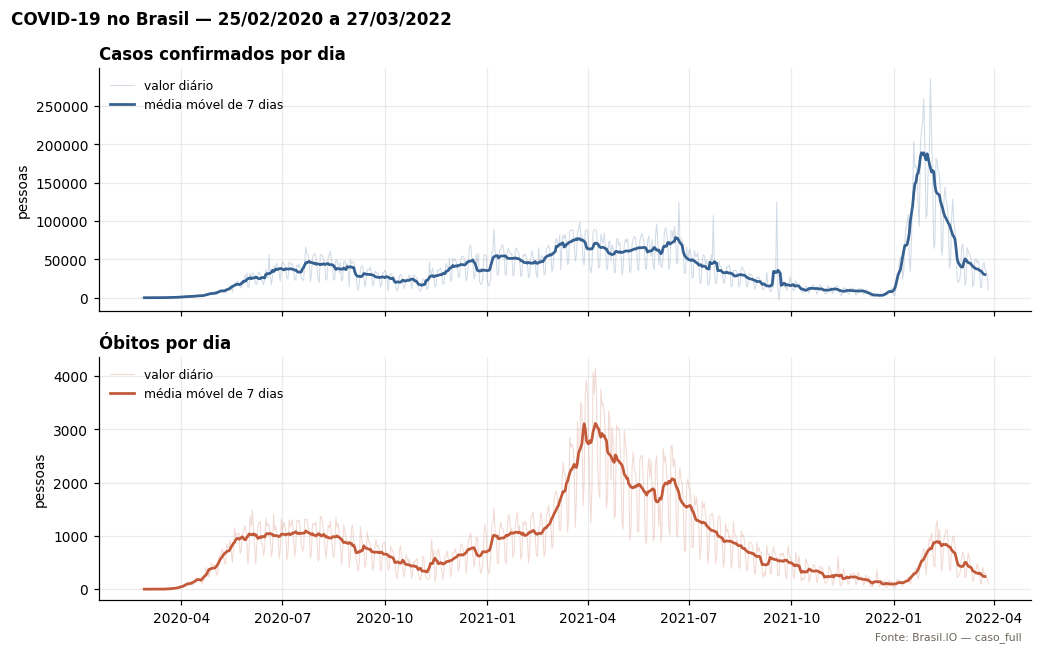

In [3]:
fig, eixos = plt.subplots(2, 1, figsize=(9.5, 6), sharex=True)

for ax, coluna, mm, cor, titulo in [
    (eixos[0], "new_confirmed", "casos_mm7", AZUL, "Casos confirmados por dia"),
    (eixos[1], "new_deaths", "obitos_mm7", VERMELHO, "Óbitos por dia"),
]:
    ax.plot(brasil.index, brasil[coluna], color=cor, alpha=.22, lw=.7, label="valor diário")
    ax.plot(brasil.index, brasil[mm], color=cor, lw=1.8, label="média móvel de 7 dias")
    ax.set_title(titulo, loc="left", fontweight="bold")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    ax.set_ylabel("pessoas")

creditar(eixos[1])
fig.suptitle("COVID-19 no Brasil — 25/02/2020 a 27/03/2022", x=.01, ha="left",
             fontweight="bold", fontsize=11)
salvar(fig, "01_curva_brasil")
plt.show()

### As ondas

Picos detectados sobre a média móvel, exigindo pelo menos 90 dias entre eles e uma
proeminência de 15% do pico máximo — sem esses limites, oscilações de curto prazo e os
ombros de uma mesma onda seriam contados como ondas separadas.

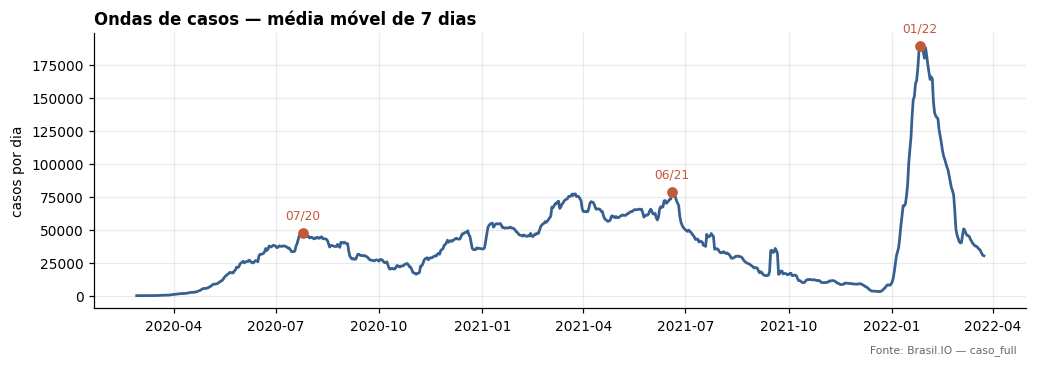

A onda de 2021 é prolongada: além do pico detectado, há um segundo cume em março
de 2021, quando os óbitos atingiram o máximo da série.


,pico em,casos/dia no pico
0,25/07/2020,47515
1,19/06/2021,78663
2,26/01/2022,189243


In [4]:
serie = brasil["casos_mm7"].dropna()
picos, _ = find_peaks(serie.values, distance=90, prominence=serie.max() * .15)

ondas = pd.DataFrame({
    "pico em": serie.index[picos].strftime("%d/%m/%Y"),
    "casos/dia no pico": serie.values[picos].round(0).astype(int),
})

fig, ax = plt.subplots(figsize=(9.5, 3.4))
ax.plot(serie.index, serie, color=AZUL, lw=1.8)
ax.plot(serie.index[picos], serie.values[picos], "o", color=VERMELHO, ms=6)
for i in picos:
    ax.annotate(f"{serie.index[i]:%m/%y}", (serie.index[i], serie.values[i]),
                textcoords="offset points", xytext=(0, 9), ha="center",
                fontsize=8, color=VERMELHO)
ax.set_title("Ondas de casos — média móvel de 7 dias", loc="left", fontweight="bold")
ax.set_ylabel("casos por dia")
creditar(ax)
salvar(fig, "02_ondas")
plt.show()

print("A onda de 2021 é prolongada: além do pico detectado, há um segundo cume em março")
print("de 2021, quando os óbitos atingiram o máximo da série.")
ondas

## 2. As UFs não foram iguais

Comparar números absolutos entre São Paulo e Acre mede população, não epidemia. Tudo aqui
é **por 100 mil habitantes**, usando `estimated_population`.

In [5]:
final = ufs.sort_values("date").groupby("state", observed=True).tail(1).set_index("state")

ranking = pd.DataFrame({
    "populacao": final["estimated_population"],
    "casos": final["last_available_confirmed"],
    "obitos": final["last_available_deaths"],
})
ranking["casos_100k"] = ranking["casos"] / ranking["populacao"] * 1e5
ranking["obitos_100k"] = ranking["obitos"] / ranking["populacao"] * 1e5
ranking["letalidade_%"] = ranking["obitos"] / ranking["casos"] * 100
ranking = ranking.sort_values("casos_100k", ascending=False).round(1)

print("Incidência por 100 mil — extremos")
print(f"  maior: {ranking.index[0]} com {ranking['casos_100k'].iloc[0]:,.0f}".replace(",", "."))
print(f"  menor: {ranking.index[-1]} com {ranking['casos_100k'].iloc[-1]:,.0f}".replace(",", "."))
print(f"  razão entre os extremos: {ranking['casos_100k'].iloc[0] / ranking['casos_100k'].iloc[-1]:.1f}x")
ranking

Incidência por 100 mil — extremos
  maior: ES com 25.521
  menor: MA com 5.962
  razão entre os extremos: 4.3x


,populacao,casos,obitos,casos_100k,obitos_100k,letalidade_%
state,,,,,,
ES,4064052,1037188,14323,25521.0,352.4,1.4
RR,631181,155062,2144,24567.0,339.7,1.4
SC,7252502,1671175,21648,23042.7,298.5,1.3
DF,3055149,691353,11573,22629.1,378.8,1.7
RO,1796460,391943,7172,21817.5,399.2,1.8
PR,11516840,2407960,42896,20908.2,372.5,1.8
MT,3526220,724653,14854,20550.4,421.2,2.0
RS,11422973,2263880,38985,19818.7,341.3,1.7
TO,1590248,302502,4142,19022.3,260.5,1.4


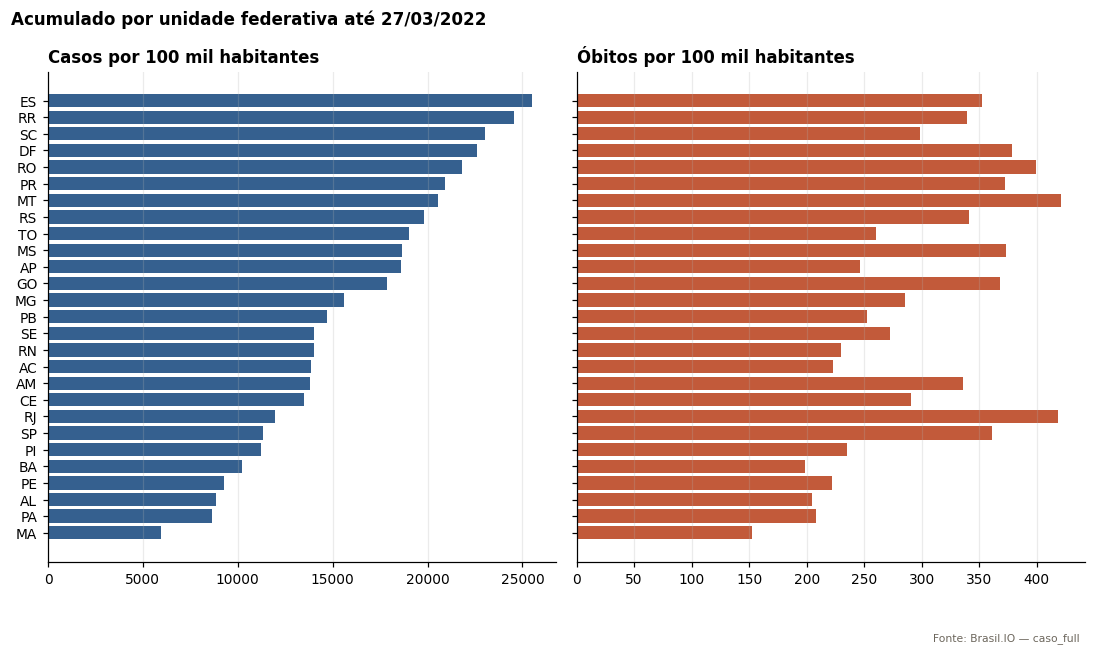

In [6]:
fig, eixos = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

por_casos = ranking.sort_values("casos_100k")
eixos[0].barh(por_casos.index, por_casos["casos_100k"], color=AZUL)
eixos[0].set_title("Casos por 100 mil habitantes", loc="left", fontweight="bold")

eixos[1].barh(por_casos.index, por_casos["obitos_100k"], color=VERMELHO)
eixos[1].set_title("Óbitos por 100 mil habitantes", loc="left", fontweight="bold")

for ax in eixos:
    ax.grid(axis="y", visible=False)
creditar(eixos[1])
fig.suptitle("Acumulado por unidade federativa até 27/03/2022", x=.01, ha="left",
             fontweight="bold", fontsize=11)
salvar(fig, "03_ranking_ufs")
plt.show()

## 3. A letalidade aparente caiu

`last_available_death_rate` é a razão entre óbitos e casos acumulados — **letalidade
aparente**, não letalidade real. Ela depende de quanto se testou: quanto mais testes,
mais casos leves entram no denominador e menor fica a razão.

A queda ao longo de 2021 combina duas causas — vacinação reduzindo óbitos e ampliação da
testagem aumentando casos detectados. A série não permite separar as duas, e o relatório
precisa dizer isso.

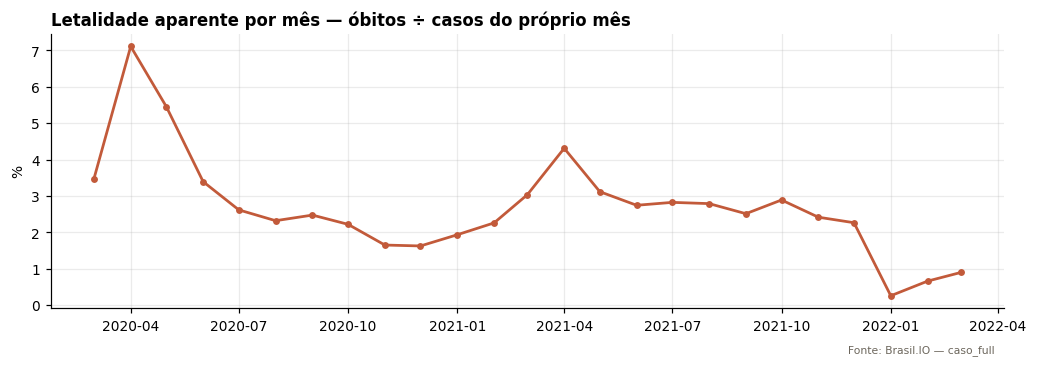

máxima: 7.1% em 04/2020
mínima: 0.3% em 01/2022


In [7]:
mensal = brasil.resample("MS")[["new_confirmed", "new_deaths"]].sum()
# Fevereiro e março de 2020 têm poucas centenas de casos: a razão oscila de forma
# violenta e não diz nada. O corte evita ler ruído como queda de letalidade.
mensal = mensal[mensal["new_confirmed"] > 1_000]
mensal["letalidade_%"] = mensal["new_deaths"] / mensal["new_confirmed"] * 100

fig, ax = plt.subplots(figsize=(9.5, 3.4))
ax.plot(mensal.index, mensal["letalidade_%"], color=VERMELHO, lw=1.8, marker="o", ms=3.5)
ax.set_title("Letalidade aparente por mês — óbitos ÷ casos do próprio mês",
             loc="left", fontweight="bold")
ax.set_ylabel("%")
creditar(ax)
salvar(fig, "04_letalidade")
plt.show()

print(f"máxima: {mensal['letalidade_%'].max():.1f}% em {mensal['letalidade_%'].idxmax():%m/%Y}")
print(f"mínima: {mensal['letalidade_%'].min():.1f}% em {mensal['letalidade_%'].idxmin():%m/%Y}")

## 4. A distribuição entre municípios, antes e depois de normalizar

Daqui em diante, o nível municipal — **recortado em 16/09/2021**, porque depois disso as
séries começam a congelar (notebook 01, seção 7).

Esta seção responde de forma medida a uma decisão que vinha sendo tomada por princípio:
**normalizar por 100 mil habitantes muda mesmo alguma coisa?**

In [8]:
municipios = carregar_municipios(
    ["date", "city", "city_ibge_code", "state", "new_confirmed", "new_deaths",
     "estimated_population"]
)
municipios = municipios[
    municipios["city_ibge_code"].notna() & (municipios["date"] <= CORTE_MUNICIPAL)
]

perfil = municipios.groupby("city_ibge_code", observed=True).agg(
    city=("city", "first"),
    state=("state", "first"),
    populacao=("estimated_population", "max"),
    casos=("new_confirmed", "sum"),
    obitos=("new_deaths", "sum"),
)
perfil = perfil[perfil["populacao"] > 0]
perfil["casos_100k"] = perfil["casos"] / perfil["populacao"] * 1e5
perfil["obitos_100k"] = perfil["obitos"] / perfil["populacao"] * 1e5

from scipy.stats import skew

print(f"municípios: {len(perfil):,}".replace(",", "."))
comparacao = pd.DataFrame({
    "casos absolutos": perfil["casos"],
    "casos por 100 mil": perfil["casos_100k"],
    "população": perfil["populacao"],
}).agg(["mean", "median", "max"]).round(0)
comparacao.loc["assimetria"] = [skew(perfil["casos"]), skew(perfil["casos_100k"]),
                                skew(perfil["populacao"])]
print()
print(comparacao.round(2).to_string())

municípios: 5.570

            casos absolutos  casos por 100 mil    população
mean                 3757.0             9835.0     38017.00
median                971.0             9457.0     11666.00
max                951578.0            47189.0  12325232.00
assimetria             28.7                0.8        37.16


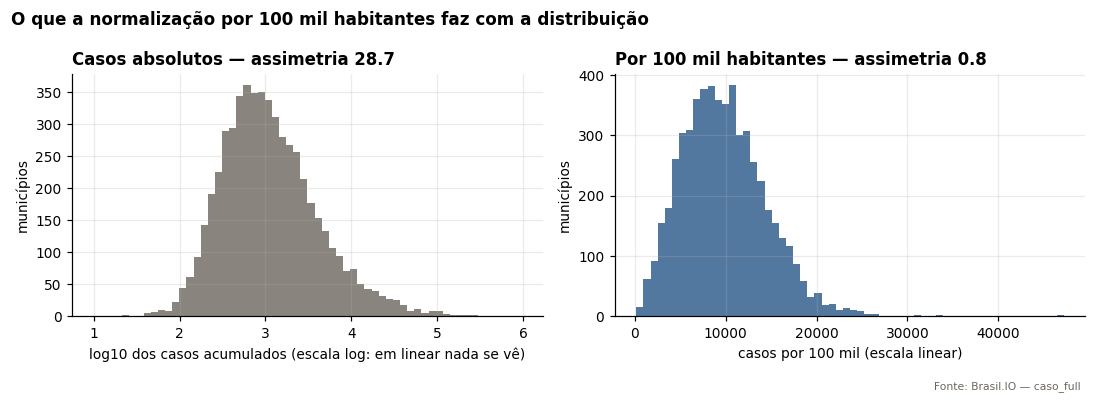

In [9]:
fig, eixos = plt.subplots(1, 2, figsize=(10, 3.6))

positivos = perfil.loc[perfil["casos"] > 0, "casos"]
eixos[0].hist(np.log10(positivos), bins=60, color=CINZA, alpha=.8)
eixos[0].set_title(f"Casos absolutos — assimetria {skew(perfil['casos']):.1f}",
                   loc="left", fontweight="bold")
eixos[0].set_xlabel("log10 dos casos acumulados (escala log: em linear nada se vê)")

eixos[1].hist(perfil["casos_100k"], bins=60, color=AZUL, alpha=.85)
eixos[1].set_title(f"Por 100 mil habitantes — assimetria {skew(perfil['casos_100k']):.1f}",
                   loc="left", fontweight="bold")
eixos[1].set_xlabel("casos por 100 mil (escala linear)")

for ax in eixos:
    ax.set_ylabel("municípios")
creditar(eixos[1], y=-.30)
fig.suptitle("O que a normalização por 100 mil habitantes faz com a distribuição",
             x=.01, ha="left", fontweight="bold", fontsize=11)
salvar(fig, "05_distribuicao_municipios")
plt.show()

A resposta é clara. Em **casos absolutos** a distribuição é extremamente assimétrica
(assimetria acima de 28), porque ela está medindo população, não epidemia — e a população
municipal brasileira é ainda mais desigual (assimetria acima de 37). Só em escala
logarítmica o histograma é legível.

**Por 100 mil habitantes** a assimetria cai para menos de 1 e a distribuição fica próxima
do simétrico, com uma cauda direita moderada. É a confirmação empírica de que a
normalização não é formalidade: sem ela, qualquer agrupamento de municípios separaria
cidades grandes de pequenas e chamaria isso de padrão epidemiológico.

Ainda assim a dispersão é grande — o percentil 99 tem cerca de **14 vezes** a incidência do
percentil 1 —, o que mantém de pé duas decisões: **padronizar os atributos** antes do
agrupamento e preferir a **mediana** ao resumir municípios.

## 5. Porte do município e formato da curva

In [10]:
faixas = pd.cut(
    perfil["populacao"],
    bins=[0, 5_000, 20_000, 100_000, 500_000, np.inf],
    labels=["até 5 mil", "5–20 mil", "20–100 mil", "100–500 mil", "mais de 500 mil"],
)

resumo = perfil.groupby(faixas, observed=True).agg(
    municipios=("casos", "size"),
    populacao_total=("populacao", "sum"),
    casos_100k_mediana=("casos_100k", "median"),
    obitos_100k_mediana=("obitos_100k", "median"),
).round(0)
resumo["% da população"] = (resumo["populacao_total"] / perfil["populacao"].sum() * 100).round(1)
resumo

,municipios,populacao_total,casos_100k_mediana,obitos_100k_mediana,% da população
populacao,,,,,
até 5 mil,1249,4186350,9932.0,193.0,2.0
5–20 mil,2534,27611400,8929.0,181.0,13.0
20–100 mil,1461,57978667,9713.0,207.0,27.4
100–500 mil,277,54457497,10583.0,287.0,25.7
mais de 500 mil,49,67521778,10669.0,338.0,31.9


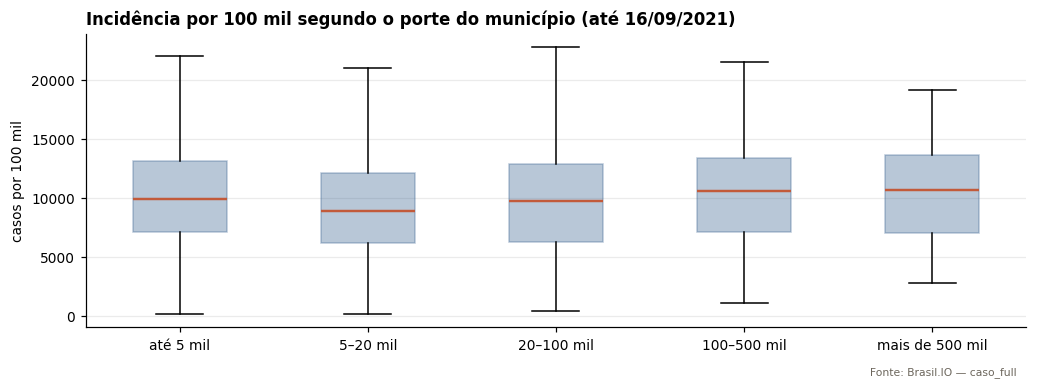

In [11]:
fig, ax = plt.subplots(figsize=(9.5, 3.6))
dados = [perfil.loc[faixas == f, "casos_100k"].values for f in faixas.cat.categories]
caixas = ax.boxplot(dados, tick_labels=list(faixas.cat.categories),
                    showfliers=False, patch_artist=True)
for caixa in caixas["boxes"]:
    caixa.set(facecolor=AZUL, alpha=.35, edgecolor=AZUL)
for mediana in caixas["medians"]:
    mediana.set(color=VERMELHO, lw=1.6)

ax.set_title("Incidência por 100 mil segundo o porte do município (até 16/09/2021)",
             loc="left", fontweight="bold")
ax.set_ylabel("casos por 100 mil")
ax.grid(axis="x", visible=False)
creditar(ax)
salvar(fig, "06_porte_municipio")
plt.show()

## 6. O represamento de fim de semana

Confirma por que toda série diária deste conjunto precisa de média móvel de 7 dias.

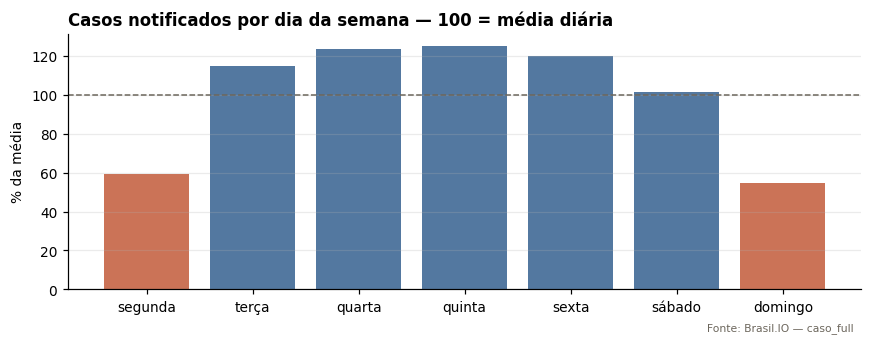

segunda     60.0
terça      115.0
quarta     124.0
quinta     125.0
sexta      120.0
sábado     102.0
domingo     55.0

menor dia (domingo): 55% da média
maior dia (quinta): 125% da média


In [12]:
DIAS = ["segunda", "terça", "quarta", "quinta", "sexta", "sábado", "domingo"]
por_dia = brasil.groupby(brasil.index.dayofweek)["new_confirmed"].mean()
por_dia.index = DIAS
relativo = por_dia / por_dia.mean() * 100

fig, ax = plt.subplots(figsize=(8, 3.2))
cores = [VERMELHO if v < 100 else AZUL for v in relativo]
ax.bar(relativo.index, relativo.values, color=cores, alpha=.85)
ax.axhline(100, color=CINZA, lw=1, ls="--")
ax.set_title("Casos notificados por dia da semana — 100 = média diária",
             loc="left", fontweight="bold")
ax.set_ylabel("% da média")
ax.grid(axis="x", visible=False)
creditar(ax)
salvar(fig, "07_dia_da_semana")
plt.show()

print(relativo.round(0).to_string())
print(f"\nmenor dia ({relativo.idxmin()}): {relativo.min():.0f}% da média")
print(f"maior dia ({relativo.idxmax()}): {relativo.max():.0f}% da média")

## Variáveis relevantes para a modelagem

Fecha a atividade *"Identificar variáveis relevantes para o problema de pesquisa"*
(vence em 20/09). A tabela abaixo é salva e vai para o Relatório Parcial.

In [13]:
variaveis = pd.DataFrame([
    ("new_confirmed", "ambas", "Série principal de casos; base de toda média móvel"),
    ("new_deaths", "ambas", "Série principal de óbitos"),
    ("estimated_population", "ambas", "Normalização por 100 mil — sem ela nada é comparável"),
    ("date", "ambas", "Eixo temporal; origem das defasagens e do dia da semana"),
    ("state", "ambas", "Agregação estadual e recorte regional"),
    ("city_ibge_code", "agrupamento", "Chave do município"),
    ("place_type", "ambas", "Separa os níveis; evita contagem em dobro"),
    ("is_last", "qualidade", "Detecta o congelamento das séries municipais"),
    ("is_repeated", "qualidade", "Identifica dias sem boletim"),
    ("epidemiological_week", "previsão", "Sazonalidade da notificação"),
    ("last_available_confirmed", "agrupamento", "Acumulado, base da incidência"),
    ("last_available_deaths", "agrupamento", "Acumulado, base da mortalidade e da letalidade"),
    ("estimated_population_2019", "descartada", "Redundante com estimated_population"),
    ("order_for_place", "descartada", "Índice interno da base"),
    ("last_available_date", "descartada", "Coberta por date e is_repeated"),
    ("last_available_confirmed_per_100k_inhabitants", "descartada",
     "Recalculada a partir dos acumulados, para manter o mesmo critério nos dois níveis"),
    ("city", "descartada", "Identificação apenas; city_ibge_code é a chave"),
], columns=["variavel", "uso", "justificativa"])

destino = CAMINHOS.resultados / "variaveis_relevantes.csv"
variaveis.to_csv(destino, index=False, encoding="utf-8")
print(f"Salvo em {destino.relative_to(CAMINHOS.raiz)}\n")
variaveis

Salvo em resultados/variaveis_relevantes.csv



,variavel,uso,justificativa
0,new_confirmed,ambas,Série principal de casos; base de toda média m...
1,new_deaths,ambas,Série principal de óbitos
2,estimated_population,ambas,Normalização por 100 mil — sem ela nada é comp...
3,date,ambas,Eixo temporal; origem das defasagens e do dia ...
4,state,ambas,Agregação estadual e recorte regional
5,city_ibge_code,agrupamento,Chave do município
6,place_type,ambas,Separa os níveis; evita contagem em dobro
7,is_last,qualidade,Detecta o congelamento das séries municipais
8,is_repeated,qualidade,Identifica dias sem boletim
9,epidemiological_week,previsão,Sazonalidade da notificação


## Conclusões desta etapa

1. **Três ondas**, com picos em julho de 2020, junho de 2021 e janeiro de 2022. A de 2021 é
   prolongada e traz um segundo cume em março, quando os óbitos chegaram ao máximo da série
   (3.112 por dia). O pico de casos da Ômicron, quase 190 mil por dia, só é visível no nível
   estadual — no municipal ele foi perdido pelo congelamento das séries.
2. **As UFs são muito desiguais** mesmo depois de normalizar por 100 mil habitantes: a
   incidência do primeiro colocado é mais de **quatro vezes** a do último. Justifica tratar
   a UF como atributo e nunca comparar valores absolutos.
3. **A letalidade aparente cai ao longo de 2021**, combinando vacinação e ampliação da
   testagem. A série não separa as duas causas — é interpretação, não medição.
4. **A normalização por 100 mil foi validada com número.** Em casos absolutos a assimetria
   entre municípios passa de 28 e reflete população; por 100 mil ela cai para menos de 1.
   A dispersão restante ainda é ampla, então padronize os atributos e use mediana ao resumir.
5. **O porte do município muda o nível da incidência**, o que torna a população um atributo
   necessário no agrupamento.
6. **O represamento de fim de semana é grande o bastante** para distorcer qualquer série
   diária. Média móvel de 7 dias em tudo.

**Próximo passo:** `03_features_modelagem.ipynb`, na Quinzena 4 — aplicar o tratamento e
construir as duas tabelas de modelagem.